## PARTE 1: DEEP LEARNING E IA GENERATIVA

Laura Somolinos Sierra y Alejandro Blanco Castellanos

### Obtenición de ángulos en flechas sobre el pavimento

Utilizar una red YOLO-OBB no nos sirve porque no obtendríamos la orientación, sino el rectángulo rotado que mejor encaja con el objeto.

La propuesta para obtener la orientación de las flechas consiste en diseñar una CNN ad-hoc que entrenaremos con las imágenes de las flechas extraidas por YOLO y la rotación proporcionada en los labels.

Para ello se eliminarán todas las imágenes que no tienen flechas, y de las que sí tienen se recortará cada flecha (puede haber varias y se reescalará a unas dimensiones fijas (por determinar), añadiendo el ángulo reportado en los labels.

Con ese dataset se entrenará una red tipo VGG para obtener dada una imagen de una flecha el ángulo que forma.

In [1]:
###
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
#!pip install opencv-python

In [2]:
###
import os
import pandas as pd
import numpy as np
import cv2

import matplotlib.pyplot as plt

def load_samples (directory, size=None):
    data = pd.read_csv(directory, sep='\t', header=None) 

    #data = data[:10]
    print(data)
    
    X = []
    Y = []
    for i in range(len(data)):
        print('.', end='')
        # carga la imagen
        imgname = data.iloc[i,0]
        img = cv2.imread(imgname)
        if size != None:
            img = cv2.resize(img, size)
        X.append(img)
        Y.append(data.iloc[i,1])

    return (np.array(X), np.array(Y))

In [3]:
###
X, Y = load_samples("dataset_cleaned.csv",(64,64)) # for model that require higher than 64x64 resolution

                                                   0         1
0        dataset/lyrs=y&x=498928&y=388383&z=20-0.png  0.747256
1        dataset/lyrs=y&x=498933&y=388386&z=20-1.png  0.085187
2        dataset/lyrs=y&x=498934&y=388391&z=20-2.png  0.634782
3        dataset/lyrs=y&x=498934&y=388391&z=20-3.png  0.140102
4        dataset/lyrs=y&x=498940&y=388395&z=20-4.png  0.887765
...                                              ...       ...
6696  dataset/lyrs=y&x=530663&y=391686&z=20-7116.png  0.514914
6697  dataset/lyrs=y&x=530669&y=391622&z=20-7117.png  0.385349
6698  dataset/lyrs=y&x=530672&y=391647&z=20-7118.png  0.652626
6699  dataset/lyrs=y&x=530676&y=391636&z=20-7119.png  0.598877
6700  dataset/lyrs=y&x=530680&y=391631&z=20-7120.png  0.615035

[6701 rows x 2 columns]
...........................................................................................................................................................................................................................

In [4]:
###
print(X.shape)
print(Y.shape)

# get train and test sets
import sklearn.model_selection

X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.10, random_state=42) # this random_state is similar to the bootstrap results

(6701, 64, 64, 3)
(6701,)


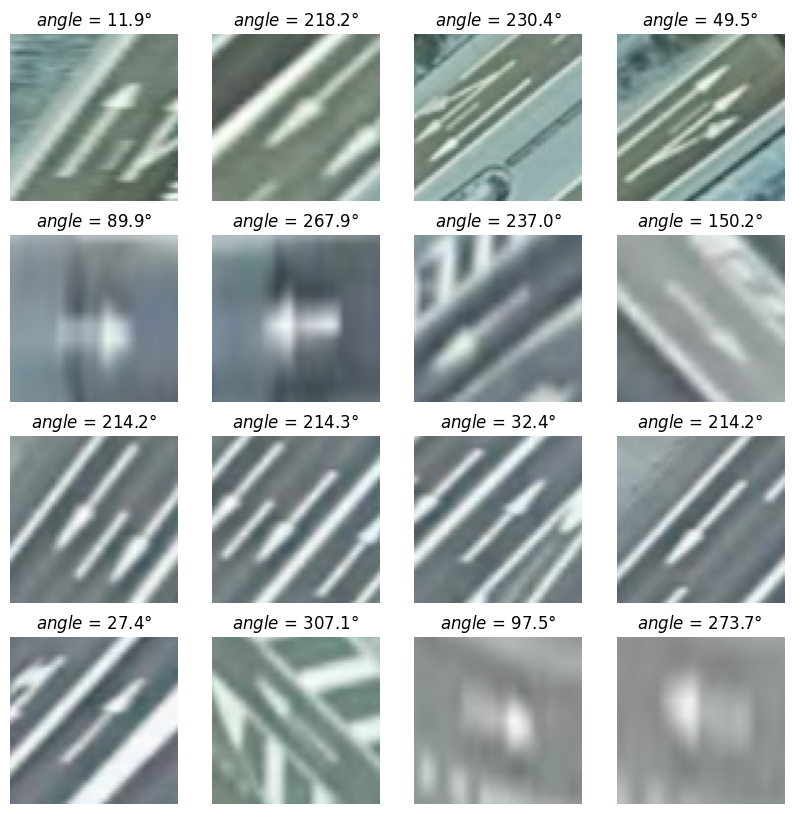

In [5]:
# imprime algunos ejemplos

N = 16

fig, axs = plt.subplots(N//4,4,figsize=(10, 10*N//16))
axs = axs.flatten()
plt.axis('off')

im0 = 567
for i in range(N):
    axs[i].axis('off')
    axs[i].imshow(X[im0+i])
    #axs[i].title.set_text(f"$angle$ = {(Y[im0+i]):.3f}")
    axs[i].title.set_text(f"$angle$ = {(360*Y[im0+i]):.1f}°")

#plt.savefig("test.png", bbox_inches='tight')

## Preparación para PyTorch

Vamos a resolver la práctica como una regresión angular.  
En lugar de predecir directamente el ángulo, se predicen sus componentes:

- $\sin(\theta)$
- $\cos(\theta)$

Esto evita el problema de discontinuidad entre $0^\circ$ y $360^\circ$.

In [7]:
###
# importamos librerias para deep learning
import math
import copy
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.10.0+cu128
Device: cuda


## Separación train / validación / test

La validación se extrae solo del conjunto de entrenamiento. Se utiliza un conjunto de validación separado del conjunto de entrenamiento para monitorizar el rendimiento del modelo durante el entrenamiento. Esto permite observar la evolución de la pérdida en datos no utilizados para ajustar los pesos y detectar posibles problemas de sobreajuste.

In [8]:
###
# Convertimos el ángulo normalizado Y en radianes
# En el notebook original se visualiza como 360 * Y
angles_train = 2 * np.pi * Y_train.astype(np.float32)
angles_test  = 2 * np.pi * Y_test.astype(np.float32)

# Etiquetas como [sin(theta), cos(theta)]
Y_train_vec = np.stack([np.sin(angles_train), np.cos(angles_train)], axis=1).astype(np.float32)
Y_test_vec  = np.stack([np.sin(angles_test),  np.cos(angles_test)], axis=1).astype(np.float32)

# Validación extraída solo de train
X_train_final, X_val, Y_train_final_vec, Y_val_vec, angles_train_final, angles_val = sklearn.model_selection.train_test_split(
    X_train,
    Y_train_vec,
    angles_train,
    test_size=0.15,
    random_state=42
)

print("X_train_final:", X_train_final.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train_final: (5125, 64, 64, 3)
X_val: (905, 64, 64, 3)
X_test: (671, 64, 64, 3)


## Dataset y transforms

Para este problema se construye un dataset personalizado ArrowDataset que tiene como objetivo unificar la carga de datos y devolver en cada iteración:
1. la imagen lista para la red,
2. su etiqueta de entrenamiento,
3. su ángulo real.

Las transformaciones permiten adaptar las imágenes al modelo y mejorar la generalización:

- Cada arquitectura espera una resolución concreta  64x64 para la CNN propia, 224x224 para VGG16.
- La normalización es necesaria en modelos preentrenados (como VGG16 con estadísticas de ImageNet).
- Data augmentation (si se añade): ayuda a tener mejores resultados frente a cambios de iluminación, ruido o pequeñas variaciones.

Si transform=None, el dataset aplica un preprocesado básico (tensor + escala [0,1]), válido para pruebas rápidas.
Las transformaciones se definen al crear cada dataset (train, val, test):

- Train: puede incluir augmentations + resize + normalización.
- Validación/Test: (resize + normalización), sin augmentations.

Esto entrena con variabilidad en train, pero se evalúa de forma estable y en val/test.

In [9]:
###
#dataset personalizado para el problema de detección de ángulos en flechas
class ArrowDataset(Dataset):
    def __init__(self, images, labels, angles, transform=None):
        # images: array numpy con las imágenes en formato BGR (cargadas con OpenCV)
        # labels: array con los vectores [sin(θ), cos(θ)] de cada imagen
        # angles: array con los ángulos en radianes de cada imagen
        # transform: transformaciones opcionales a aplicar sobre las imágenes
        self.images = images
        self.labels = labels
        self.angles = angles
        self.transform = transform

    def __len__(self):
        #num total muestras del dataset
        return len(self.images)

    def __getitem__(self, idx):
        # muestra por indice devuelve la imagen transformada, el vector etiqueta y el ángulo en radianes
        # carga en BGR y convierte a RGB, si hay transformaciones las aplica, sino normaliza a [0,1] y convierte a tensor
        img = self.images[idx]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        angle = torch.tensor(self.angles[idx], dtype=torch.float32)
        return img, label, angle

# Transformaciones para CNN propia y VGG16
transform_cnn = transforms.Compose([transforms.ToPILImage(), transforms.Resize((64, 64)), transforms.ToTensor()])

# Para VGG16 se necesitan imágenes de 224x224 y normalizadas con los valores de mean y std de ImageNet para cada RGB
# los valores de mean y std son los que se usan para normalizar las imágenes de entrada a VGG16 -> BatchNorm de VGG16
transform_vgg = transforms.Compose([transforms.ToPILImage(), transforms.Resize((224, 224)), transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

BATCH_SIZE = 32 #tamaño de batch para entrenamiento y evaluación

# Datasets para CNN propia
train_dataset_cnn = ArrowDataset(X_train_final, Y_train_final_vec, angles_train_final, transform=transform_cnn)
val_dataset_cnn   = ArrowDataset(X_val, Y_val_vec, angles_val, transform=transform_cnn)
test_dataset_cnn  = ArrowDataset(X_test, Y_test_vec, angles_test, transform=transform_cnn)

# Datasets para VGG16
train_dataset_vgg = ArrowDataset(X_train_final, Y_train_final_vec, angles_train_final, transform=transform_vgg)
val_dataset_vgg   = ArrowDataset(X_val, Y_val_vec, angles_val, transform=transform_vgg)
test_dataset_vgg  = ArrowDataset(X_test, Y_test_vec, angles_test, transform=transform_vgg)

# shuffle True para entrenamiento, False para validación y test porque no queremos que el orden de las muestras afecte el entrenamiento
# shuffle False para validación y test porque queremos evaluar siempre con el mismo orden de muestras para comparar 
train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(val_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn  = DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False)

train_loader_vgg = DataLoader(train_dataset_vgg, batch_size=BATCH_SIZE, shuffle=True)
val_loader_vgg   = DataLoader(val_dataset_vgg, batch_size=BATCH_SIZE, shuffle=False)
test_loader_vgg  = DataLoader(test_dataset_vgg, batch_size=BATCH_SIZE, shuffle=False)

## Modelo 1: CNN ad-hoc tipo VGG

In [10]:
class CustomVGG(nn.Module):
    def __init__(self):
        super().__init__()
        '''Una CNN inspirada en VGG pero más ligera, con bloques de convolución 
        seguidos de BatchNorm y ReLU, y un clasificador con Dropout para evitar 
        overfitting.'''
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x
    
custom_model = CustomVGG().to(device)
custom_model

CustomVGG(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1,

## Modelo 2: VGG16 con transfer learning

In [11]:
class VGG16Regressor(nn.Module):
    def __init__(self):
        super().__init__()
        ''' Modelo de VGG16 con transfer learning (pesos preentrenados de ImageNet)'''

        # Intenta cargar pesos preentrenados; si falla, usa la arquitectura sin pesos.
        try:
            self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            print("VGG16 cargada con pesos preentrenados de ImageNet.")
        except Exception as e:
            print("No se pudieron descargar/cargar los pesos preentrenados:", e)
            print("Se crea VGG16 sin pesos. Para transfer learning real, conviene ejecutar con acceso a los pesos.")
            self.vgg = models.vgg16(weights=None)

        # Congelamos la parte convolucional
        for param in self.vgg.features.parameters():
            param.requires_grad = False

        self.vgg.classifier = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(128, 2),
            nn.Tanh()
        )

    def forward(self, x):
        return self.vgg(x)


vgg_model = VGG16Regressor().to(device)

VGG16 cargada con pesos preentrenados de ImageNet.


## Funciones de entrenamiento y evaluación

Creamos distintas funciones que nos ayudarán a entrenar y evaluar cada modelo posterior.


Lo primero es elegir como Loss nn.SmoothL1Loss(). Se usa porque la salida es regresión ([sin(theta), cos(theta)]) y es más estable que MSE frente a errores grandes (menos sensibilidad a outliers).

- Creamos un train_one_epoch -> ejecuta un ciclo completo de entrenamiento sobre train_loader. Hace forward, calcula loss, backpropagation y actualización de pesos devolviendo la pérdida media de entrenamiento.

- evaluate_loss evalúa sin entrenar, solo la pérdida (model.eval() + torch.no_grad()). Da una medida limpia del rendimiento en validación/test.

- train_model-> todo el entrenamiento.

- vectors_to_angles -> Convierte la salida de la red ([sin, cos]) a ángulo en radianes y normaliza el vector.

- angular_error_deg-> Calcula el error angular real teniendo en cuenta 0° = 360°. Usa la distancia circular mínima y lo pasa a grados.

- predict_model -> Genera predicciones del modelo.

- evaluate_model -> MAE angular, mediana, accuracy ±10° y ±20°.

- plot_history -> Visualiza train_loss y val_loss por época. Para detectar convergencia y posible sobreajuste.

- show_predictions -> Muestra ejemplos cualitativos (imagen + ángulo real vs predicho + error).

In [10]:
###
criterion = nn.SmoothL1Loss()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for imgs, labels, _ in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

'''Durante la evaluación del modelo se utiliza el modo eval() de PyTorch. 
Este modo desactiva comportamientos específicos del entrenamiento en capas 
como Dropout y Batch Normalization, permitiendo obtener estimaciones más 
estables del rendimiento del modelo.
No usaremos la evaluación con la validación para ajustar hiperparametros
ya que no se encuentra entre los objetivos. Si esta red funciona bien y sin 
sobreajuste, no será necesario.'''

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=20, patience=5):
    #patience es el número de épocas que se esperará sin mejora en la pérdida de validación antes de detener el entrenamiento (early stopping)
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": []}
    patience_counter = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_state)
    return history


def vectors_to_angles(y_pred):
    norm = np.linalg.norm(y_pred, axis=1, keepdims=True) + 1e-8
    y_pred = y_pred / norm
    sin_pred = y_pred[:, 0]
    cos_pred = y_pred[:, 1]
    angles = np.arctan2(sin_pred, cos_pred)
    angles = np.mod(angles, 2*np.pi)
    return angles


def angular_error_deg(y_true_angle, y_pred_vec):
    pred_angle = vectors_to_angles(y_pred_vec)
    diff = np.abs(pred_angle - y_true_angle)
    diff = np.minimum(diff, 2*np.pi - diff)
    return np.degrees(diff)


def predict_model(model, loader, device):
    model.eval()
    preds = []
    true_angles = []

    with torch.no_grad():
        for imgs, _, angles in loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy()
            preds.append(outputs)
            true_angles.append(angles.numpy())

    preds = np.vstack(preds)
    true_angles = np.concatenate(true_angles)
    return preds, true_angles


def evaluate_model(model, loader, device, name="Modelo"):
    preds, true_angles = predict_model(model, loader, device)
    errors = angular_error_deg(true_angles, preds)

    print(f"\n{name}")
    print(f"MAE angular: {errors.mean():.2f} grados")
    print(f"Mediana error angular: {np.median(errors):.2f} grados")
    print(f"Accuracy ±10°: {(errors <= 10).mean()*100:.2f}%")
    print(f"Accuracy ±20°: {(errors <= 20).mean()*100:.2f}%")

    return errors, preds, true_angles


def plot_history(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


def show_predictions(model, dataset, device, n=6, normalize_for_display=False):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            img, _, true_angle = dataset[idx]
            output = model(img.unsqueeze(0).to(device)).cpu().numpy()
            pred_angle = vectors_to_angles(output)[0]

            img_np = img.permute(1, 2, 0).cpu().numpy()

            if normalize_for_display:
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_np = img_np * std + mean

            img_np = np.clip(img_np, 0, 1)

            true_deg = np.degrees(true_angle.item())
            pred_deg = np.degrees(pred_angle)
            err = abs(pred_deg - true_deg)
            err = min(err, 360 - err)

            plt.subplot(int(np.ceil(len(idxs)/3)), 3, i+1)
            plt.imshow(img_np)
            plt.title(f"Real: {true_deg:.1f}°\nPred: {pred_deg:.1f}°\nErr: {err:.1f}°")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

## Entrenamiento de la CNN ad-hoc

In [13]:
print("Y_train shape original:", Y_train.shape)
print("Y_train_vec shape:", Y_train_vec.shape)
print("Y_train_final_vec shape:", Y_train_final_vec.shape)

imgs, labels, angles = next(iter(train_loader_cnn))
print("imgs shape:", imgs.shape)
print("labels shape:", labels.shape)
print("angles shape:", angles.shape)

print("Primeras labels:")
print(labels[:5])

Y_train shape original: (6030,)
Y_train_vec shape: (6030, 2)
Y_train_final_vec shape: (5125, 2)
imgs shape: torch.Size([32, 3, 64, 64])
labels shape: torch.Size([32, 2])
angles shape: torch.Size([32])
Primeras labels:
tensor([[ 0.3219, -0.9468],
        [ 0.0461,  0.9989],
        [-0.7243,  0.6895],
        [ 0.7824, -0.6227],
        [-0.2757, -0.9612]])


Aquí podemos ver que la red sí que puede aprender y memorizar un subconjunto, pero debemos mejorarla porque la orientación de la flecha puede cambiar por fondo, sombras, ilumincaión... La señal útil de la flecha puede estar tapada por mucho fondo y puede que la CNN hasta ahora sea floja para ello, por ello en el entrenamiento real aprende muy poco 

In [14]:
small_indices = list(range(8))
small_subset = torch.utils.data.Subset(train_dataset_cnn, small_indices)
small_loader = DataLoader(small_subset, batch_size=8, shuffle=True)

debug_model = CustomVGG().to(device)
debug_optimizer = optim.Adam(debug_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(50):
    debug_model.train()
    for imgs, labels, _ in small_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        debug_optimizer.zero_grad()
        outputs = debug_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        debug_optimizer.step()

    if epoch % 10 == 0:
        print(epoch, loss.item())

0 0.48761090636253357
10 0.7989916801452637
20 0.4335794746875763
30 0.28911930322647095
40 0.0980253517627716


Lo hemos mejorado añadiendo BatchNorm + SmoothL1 y sin Tanh, cambiando la loss debería también mejorar la predicción.

In [15]:
custom_model = CustomVGG().to(device)
criterion = nn.SmoothL1Loss()
optimizer_custom = optim.Adam(custom_model.parameters(), lr=1e-4, weight_decay=1e-4)

history_custom = train_model(
    custom_model,
    train_loader_cnn,
    val_loader_cnn,
    criterion,
    optimizer_custom,
    device,
    epochs=25,
    patience=6
)

Epoch 01/25 | train_loss=0.18595 | val_loss=0.11262
Epoch 02/25 | train_loss=0.12114 | val_loss=0.09522
Epoch 03/25 | train_loss=0.10154 | val_loss=0.07996
Epoch 04/25 | train_loss=0.09105 | val_loss=0.07523
Epoch 05/25 | train_loss=0.07992 | val_loss=0.07027
Epoch 06/25 | train_loss=0.07332 | val_loss=0.06357
Epoch 07/25 | train_loss=0.06790 | val_loss=0.06105
Epoch 08/25 | train_loss=0.06254 | val_loss=0.06126
Epoch 09/25 | train_loss=0.05951 | val_loss=0.06154
Epoch 10/25 | train_loss=0.05305 | val_loss=0.05218
Epoch 11/25 | train_loss=0.04993 | val_loss=0.05542
Epoch 12/25 | train_loss=0.04701 | val_loss=0.05084
Epoch 13/25 | train_loss=0.04323 | val_loss=0.04618
Epoch 14/25 | train_loss=0.04092 | val_loss=0.05012
Epoch 15/25 | train_loss=0.03837 | val_loss=0.04891
Epoch 16/25 | train_loss=0.03519 | val_loss=0.04552
Epoch 17/25 | train_loss=0.03366 | val_loss=0.03959
Epoch 18/25 | train_loss=0.03293 | val_loss=0.04224
Epoch 19/25 | train_loss=0.03148 | val_loss=0.04185
Epoch 20/25 

podemos ver que la loss de el conjunto validación es mejor que la de train y eso puede ser porque en el train hemos aplicado drop out por lo que la red está funcionando con neuronas apagadas aleatoriamente y en el val se evalua con model.eval() que hace que el drop out se desactive 

La mejora del loss actual se debe a que hemos suprimido el global average pooling tan agresivo que teniamos antes que destruia la información espacial y que anteriormente no teniamos batchnorm lo cual estabiliza el entrenamiento. Por otra parte, antes aplicábamos tanh a la salida lo cual al principio del entrenamiento eso puede causar saturación y la red se quedaba estancada cerca de 0. La loss elegida, SmoothL1Loss funciona mejor que MSELoss ya que con MSE para errores grandes tenemos gradientes muy grandes y para errores pequeños gradientes muy pequeños lo cula puede causar inestabilidad. Al usar SmoothL1Loss se combinan los dos comportamientos tal que para errores pequeños funciona como MSE y para errores grandes funciona como L1 |x-y| lo cual hace un gradiente más controlado y un aprendizaje más estable.

Se puede observar que tanto en train como en eval el modelo aprende correctamente bajando bastante la loss en los distintos epochs y que no hay sobreajuste fuerte y que finalmente la loss de la validación acaba siendo algo mayor que la del entrenamiento. A partir del epoch 15-20 la validación es más lenta y eso sugiere que el modelo está cerca de su capacidad máxima para este task. Es muy importante haber añadido la validación para comprobar si el modelo generaliza correctamente cuando todas las neuronas estan activas (sin dropout) y usando para batch normalization las estadisticas acumuladas del entrenamiento.

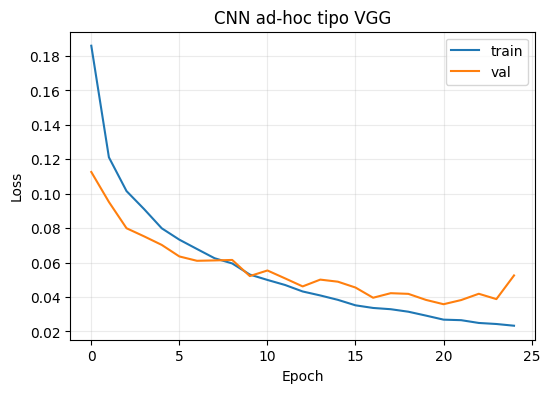

In [16]:
plot_history(history_custom, "CNN ad-hoc tipo VGG")

## Entrenamiento de VGG16 con transfer learning

In [17]:
vgg_model = VGG16Regressor().to(device)

optimizer_vgg = optim.Adam(
    filter(lambda p: p.requires_grad, vgg_model.parameters()),
    lr=1e-4
)

history_vgg = train_model(
    vgg_model,
    train_loader_vgg,
    val_loader_vgg,
    criterion,
    optimizer_vgg,
    device,
    epochs=15,
    patience=4
)

VGG16 cargada con pesos preentrenados de ImageNet.
Epoch 01/15 | train_loss=0.18728 | val_loss=0.12115
Epoch 02/15 | train_loss=0.09544 | val_loss=0.09178
Epoch 03/15 | train_loss=0.06077 | val_loss=0.08766
Epoch 04/15 | train_loss=0.04398 | val_loss=0.08028
Epoch 05/15 | train_loss=0.03138 | val_loss=0.07993
Epoch 06/15 | train_loss=0.02394 | val_loss=0.07734
Epoch 07/15 | train_loss=0.01909 | val_loss=0.07484
Epoch 08/15 | train_loss=0.01523 | val_loss=0.07438
Epoch 09/15 | train_loss=0.01348 | val_loss=0.07270
Epoch 10/15 | train_loss=0.01172 | val_loss=0.07370
Epoch 11/15 | train_loss=0.01045 | val_loss=0.07354
Epoch 12/15 | train_loss=0.00997 | val_loss=0.07231
Epoch 13/15 | train_loss=0.00931 | val_loss=0.07221
Epoch 14/15 | train_loss=0.00877 | val_loss=0.07199
Epoch 15/15 | train_loss=0.00861 | val_loss=0.07256


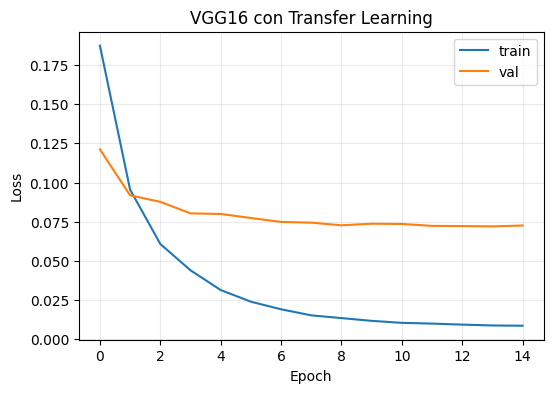

In [18]:
plot_history(history_vgg, "VGG16 con Transfer Learning")

Al igual que en nuestra CNN anterior podemos ver que la loss de el conjunto validación es mejor que la de train  al principio y tambien se debe a que en el train hemos aplicado drop out por lo que la red está funcionando con neuronas apagadas aleatoriamente y en el val se evalua con model.eval() que hace que el drop out se desactive 

## Evaluación final sobre test

In [19]:
errors_custom, preds_custom, true_custom = evaluate_model(
    custom_model, test_loader_cnn, device, "CNN ad-hoc tipo VGG"
)

errors_vgg, preds_vgg, true_vgg = evaluate_model(
    vgg_model, test_loader_vgg, device, "VGG16 Transfer Learning"
)


CNN ad-hoc tipo VGG
MAE angular: 14.02 grados
Mediana error angular: 5.71 grados
Accuracy ±10°: 71.54%
Accuracy ±20°: 88.08%

VGG16 Transfer Learning
MAE angular: 23.09 grados
Mediana error angular: 7.92 grados
Accuracy ±10°: 59.46%
Accuracy ±20°: 78.54%


## Ejemplos de predicción

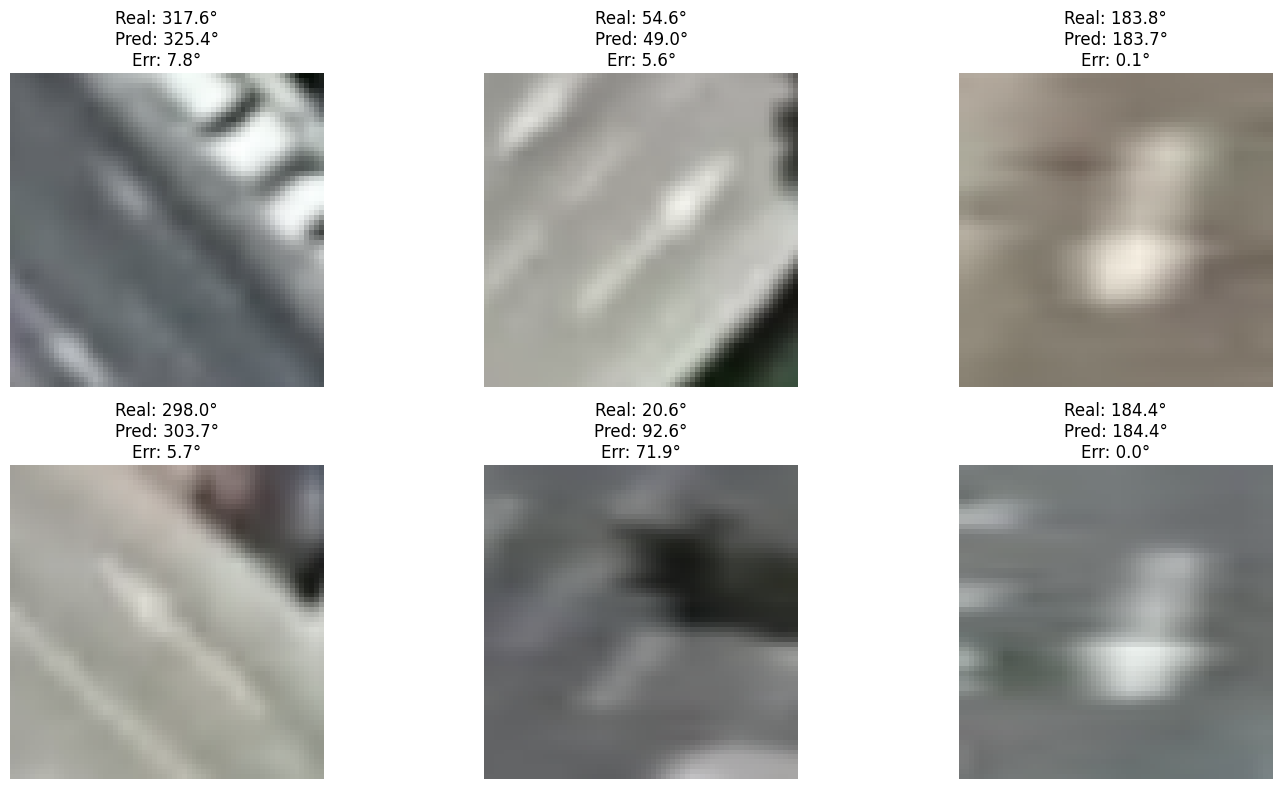

In [20]:
show_predictions(custom_model, test_dataset_cnn, device, n=6, normalize_for_display=False)

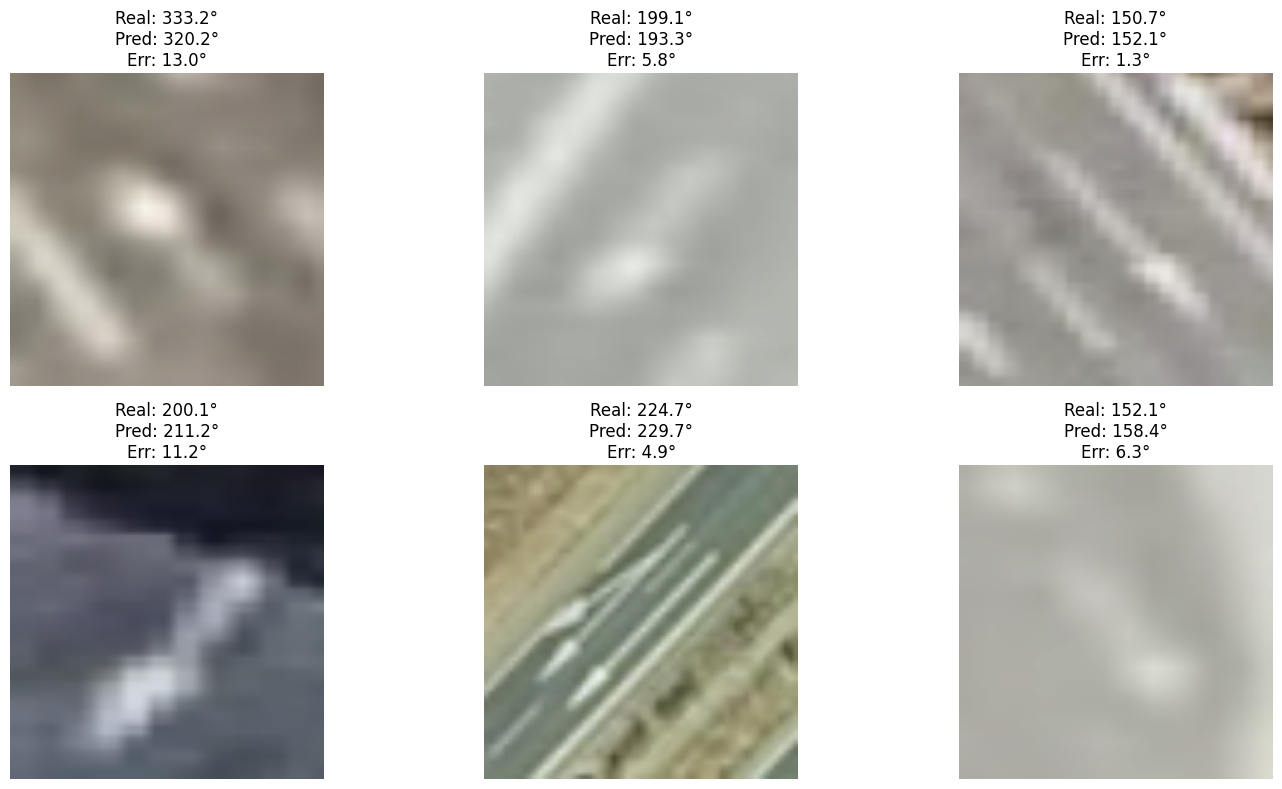

In [21]:
show_predictions(vgg_model, test_dataset_vgg, device, n=6, normalize_for_display=True)

La VGG16 te está funcionando peor que la CNN ad-hoc
Y además en VGG16 se ve esto:

train_loss baja mucho: 0.187 → 0.0086
val_loss mejora al principio, pero luego se estanca alrededor de 0.072
Esto puede ser porque estamos usando VGG16 con la parte convolucional congelada para que el entrnamiento no sea tan costoso entonces, las features no se adaptan al problema. Solo se entrena el clasificador final. Nuestro problema es muy específico entonces puede que las features preentrenadas no sean las más adecuadas para distinguir orientación angular en este tipo de imágenes (teniendo en cuenta que nuestra baseline CNN está bastante bien ajustada). Además la VGG16 usa 224x224 para redimensionar una imagen pequeña y puede empeorar la calidad útil de la señal suavizando bordes y degradando pistas de orientación.

Problemas a solucionar de VGG16:
1) las features de ImageNet no encajan de todo con el problema(normalmente usadas para clasificación)
2) Congelar toda la parte convolucional para hacer el entrenamiento menos costoso hace que se limite la red
3) redimensionar a 224x224 no ayuda

## INTENTO MEJORA VGG16 

Vamos a implementar un nuevo VGG16 basado en el anterior pero con mejoras como:
- descongelar las últimas capas convolucionales (aunque sea más costoso)
- usar learning rate pequeño 
- quitar TanH en salida como quitamos en principio en CNN
- Usar SmoothL1 como loss que nos dió buenos resultados en CNN 

In [12]:
###
class VGG16Regressor2(nn.Module):
    def __init__(self):
        super().__init__()

        self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # congelar primero todas las capas convolucionales
        for param in self.vgg.features.parameters():
            param.requires_grad = False

        # descongelar solo el último bloque convolucional
        # En VGG16, las capas del último bloque están aproximadamente desde el índice 24
        for param in self.vgg.features[24:].parameters():
            param.requires_grad = True


        # Sustituir el clasificador quitando tanh y ajustando dropout
        self.vgg.classifier = nn.Sequential(
            nn.Linear(25088, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2))

    def forward(self, x):
        return self.vgg(x)

vgg_model2 = VGG16Regressor2().to(device)
criterion = nn.SmoothL1Loss()
optimizer_vgg2 = optim.Adam(filter(lambda p: p.requires_grad, vgg_model2.parameters()),
                           lr=1e-5, weight_decay=1e-4)

0.6%

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/ablan/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [13]:
###
history_vgg2 = train_model(vgg_model2,
    train_loader_vgg,
    val_loader_vgg,
    criterion,
    optimizer_vgg2,
    device,
    epochs=15,
    patience=3)

Epoch 01/15 | train_loss=0.22126 | val_loss=0.13482
Epoch 02/15 | train_loss=0.11693 | val_loss=0.08656
Epoch 03/15 | train_loss=0.08363 | val_loss=0.07331
Epoch 04/15 | train_loss=0.06829 | val_loss=0.06499
Epoch 05/15 | train_loss=0.05703 | val_loss=0.06286
Epoch 06/15 | train_loss=0.04797 | val_loss=0.05723
Epoch 07/15 | train_loss=0.04119 | val_loss=0.05447
Epoch 08/15 | train_loss=0.03550 | val_loss=0.05218
Epoch 09/15 | train_loss=0.03104 | val_loss=0.05142
Epoch 10/15 | train_loss=0.02789 | val_loss=0.05041
Epoch 11/15 | train_loss=0.02470 | val_loss=0.04798
Epoch 12/15 | train_loss=0.02268 | val_loss=0.04860
Epoch 13/15 | train_loss=0.02088 | val_loss=0.04688
Epoch 14/15 | train_loss=0.01937 | val_loss=0.04669
Epoch 15/15 | train_loss=0.01750 | val_loss=0.04720


In [14]:
###
#evaluación del modelo 
errors_vgg2, preds_vgg2, true_vgg2 = evaluate_model(
    vgg_model2,
    test_loader_vgg,
    device,
    "VGG16 Transfer learning fine-tuning parcial")


VGG16 Transfer learning fine-tuning parcial
MAE angular: 16.56 grados
Mediana error angular: 6.53 grados
Accuracy ±10°: 62.44%
Accuracy ±20°: 83.31%


Se puede observar que mejora la solución anterior pero no nuestra CNN ad-hoc aunque el resultado parece ser bastante satisfactorio 

## Guardado de modelos

In [15]:
torch.save(vgg_model2.state_dict(), "vgg16_finetune_last_block_arrow_regressor.pth")

## Conclusiones

- El problema se ha planteado como una regresión angular sobre imágenes de flechas ya recortadas.
- Para evitar la discontinuidad entre $0^\circ$ y $360^\circ$, la red no predice directamente el ángulo, sino sus componentes $\sin(\theta)$ y $\cos(\theta)$.
- Se ha entrenado una CNN ad-hoc tipo VGG como baseline.
- También se ha usado una VGG16 preentrenada con transfer learning, reemplazando el clasificador final por regresión. 
- Se ha hecho una mejora de cara a VGG16 al visualizar que la primera aproximación es peor que el funcionamiento de nuestra CNN ad-hoc
- El conjunto de test se ha mantenido separado para la evaluación final y la validación se ha extraído únicamente del conjunto de entrenamiento.
- La comparación entre modelos se realiza mediante error angular medio en grados, mediana del error y porcentajes de acierto con tolerancias de $10^\circ$ y $20^\circ$.

Finalmente podemos concluir que si creamos nuestra propia red neuronal basada en lo que necesita el problema para ser solucionado se puede llegar a resultados bastante más satisfactorios que si importamos redes neuronales previamente construidas para problemas más generales, aunque esa opción del transfer learning tampoco funcione mal del todo si la ajustamos a nuestras necesidades.